# Assignment V — Goal-Based Portfolio Optimisation

**Objective.** Design a *static* portfolio that maximises the probability of reaching a
₹1.5 Crore retirement goal over a 20-year horizon, given two different intermediate-goal
sequences. Use brute-force search over discrete weights combined with a Monte-Carlo
simulation, then (bonus) repeat with a continuous SciPy optimiser allowing short-selling.

**Universe.** Five (assumed largely uncorrelated) Indian stocks:
`TCS.NS`, `HDFCBANK.NS`, `RELIANCE.NS`, `SUNPHARMA.NS`, `ITC.NS`.

**Plan parameters.**
- Initial savings: **₹20,000 / month**, growing at **4 % p.a.**
- Borrowing rate when an intermediate goal can't be met: **12 % p.a.**
- Horizon: **20 years**, **5,000 Monte-Carlo paths** per portfolio.


## Methodology Flowchart

```
┌─────────────────────────────────────────────────────────────┐
│  1. Download daily adjusted closing prices (yfinance)       │
│     2014-01-01 → 2023-12-31 for 5 tickers                   │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  2. Compute annualised mean μ, std σ, covariance Σ          │
│     from historical daily returns                           │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  3. Enumerate every weight tuple (w₁..w₅) ∈ {0, .25, .5,    │
│     .75, 1.0}⁵ with Σwᵢ = 1.0  →  70 valid portfolios       │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  4. Pre-sample one common asset-return tensor               │
│     shape = (5000, 20, 5)  via MVN(μ, Σ)                    │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  5. For each portfolio w, simulate 20-year wealth path:     │
│        a) add yearly savings (4 % growth)                   │
│        b) apply portfolio return                            │
│        c) accrue & repay loan @ 12 %                        │
│        d) deduct goal / borrow shortfall @ 12 %             │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  6. Success probability = P(V₂₀ − L₂₀ ≥ ₹1.5 Cr)            │
│     argmax over the 70 combos                               │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  7. Repeat for Sequence A (aggressive-early) and            │
│     Sequence B (backloaded); compare the optima             │
└──────────────────────────┬──────────────────────────────────┘
                           ▼
┌─────────────────────────────────────────────────────────────┐
│  8. BONUS — drop the discrete grid; run scipy.optimize      │
│     SLSQP with continuous weights + short-selling           │
└─────────────────────────────────────────────────────────────┘
```



## 0. Environment setup



In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize
import time, warnings

warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Parameters & Goal Sequences

In [ ]:
# ---- Universe ----
TICKERS = ['TCS.NS', 'HDFCBANK.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'ITC.NS']

# ---- Time window for parameter estimation ----
START_DATE = '2014-01-01'
END_DATE   = '2023-12-31'

# ---- Investment plan ----
HORIZON_YEARS          = 20
INITIAL_MONTHLY_SAVING = 20_000     # ₹/month, year 1
SAVINGS_GROWTH         = 0.04       # +4 % p.a.
BORROW_RATE            = 0.12       # 12 % p.a. on shortfall loans
TERMINAL_GOAL          = 1.5e7      # ₹1.5 Crore at year 20

# ---- Monte-Carlo controls ----
NUM_PATHS = 5_000
SEED      = 42

# ---- Discrete weight grid ----
DISCRETE_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]

# ---- Goal sequences (year_index : ₹ amount) ----
INTERMEDIATE_GOALS_A = {3: 15e5, 7: 25e5, 12: 30e5}    # Sequence A — aggressive early
INTERMEDIATE_GOALS_B = {8: 10e5, 12: 20e5, 16: 40e5}   # Sequence B — backloaded

print("Sequence A (aggressive-early):")
for y, a in INTERMEDIATE_GOALS_A.items():
    print(f"  Year {y:>2}:  Rs.{a/1e5:5.1f} Lakhs")
print(f"  Year 20:  Rs.{TERMINAL_GOAL/1e7:.1f} Crores  (TERMINAL)")

print("\nSequence B (backloaded):")
for y, a in INTERMEDIATE_GOALS_B.items():
    print(f"  Year {y:>2}:  Rs.{a/1e5:5.1f} Lakhs")
print(f"  Year 20:  Rs.{TERMINAL_GOAL/1e7:.1f} Crores  (TERMINAL)")

print(f"\nTotal intermediate withdrawals --  A: Rs.{sum(INTERMEDIATE_GOALS_A.values())/1e5:.0f}L, "
      f"B: Rs.{sum(INTERMEDIATE_GOALS_B.values())/1e5:.0f}L  (same total -- only timing differs!)")

Sequence A (aggressive-early):
  Year  3:  Rs. 15.0 Lakhs
  Year  7:  Rs. 25.0 Lakhs
  Year 12:  Rs. 30.0 Lakhs
  Year 20:  Rs.1.5 Crores  (TERMINAL)

Sequence B (backloaded):
  Year  8:  Rs. 10.0 Lakhs
  Year 12:  Rs. 20.0 Lakhs
  Year 16:  Rs. 40.0 Lakhs
  Year 20:  Rs.1.5 Crores  (TERMINAL)

Total intermediate withdrawals --  A: Rs.70L, B: Rs.70L  (same total -- only timing differs!)


## 2. Historical Price Data

Download daily adjusted closes for 2014-01-01 → 2023-12-31 (10 years).
With `auto_adjust=True` (the modern yfinance default) the `Close` column is already
split- and dividend-adjusted, so it equals the legacy `Adj Close`.

In [ ]:
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

prices = raw['Close'][TICKERS].ffill().dropna()
print(f"Price data shape   : {prices.shape}")
print(f"Date range         : {prices.index.min().date()} -> {prices.index.max().date()}")
prices.tail()

Price data shape   : (2465, 5)
Date range         : 2014-01-01 -> 2023-12-29


Ticker,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS
Date,,,,,
2023-12-22,3561.377197,813.178833,1273.102173,1213.405151,401.367279
2023-12-26,3534.881104,818.824402,1279.554443,1217.161377,402.469452
2023-12-27,3549.456055,828.971863,1283.922119,1221.990845,403.042572
2023-12-28,3538.932373,829.920837,1293.203369,1231.455078,409.214752
2023-12-29,3532.878174,831.867615,1282.979126,1228.820557,407.451263


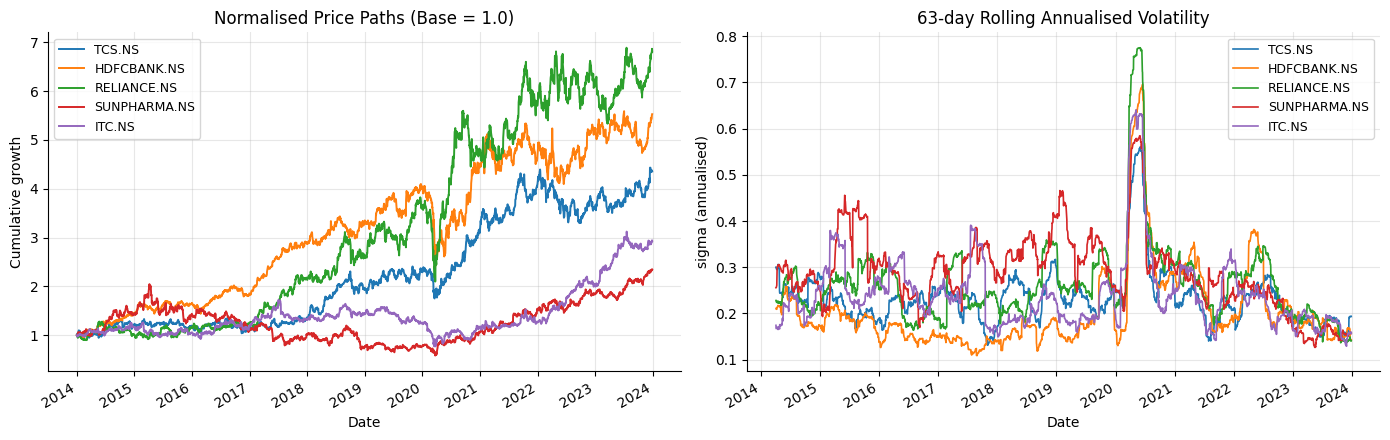

In [ ]:
# Visualise normalised price paths
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

(prices / prices.iloc[0]).plot(ax=axes[0], lw=1.4)
axes[0].set_title('Normalised Price Paths (Base = 1.0)')
axes[0].set_ylabel('Cumulative growth')
axes[0].legend(fontsize=9)

daily_returns_preview = prices.pct_change().dropna()
(daily_returns_preview.rolling(63).std() * np.sqrt(252)).plot(ax=axes[1], lw=1.2)
axes[1].set_title('63-day Rolling Annualised Volatility')
axes[1].set_ylabel('sigma (annualised)')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

## 3. Annualised Return, Volatility & Covariance

We compute these from daily simple returns and annualise with the standard
252 trading-day convention:

$$
\hat\mu_{\text{ann}} = 252\,\bar r_{\text{daily}}, \qquad
\hat\Sigma_{\text{ann}} = 252\,\hat\Sigma_{\text{daily}}.
$$

In [ ]:
TRADING_DAYS = 252

daily_returns = prices.pct_change().dropna()
mu_annual    = daily_returns.mean() * TRADING_DAYS
sigma_annual = daily_returns.std()  * np.sqrt(TRADING_DAYS)
cov_annual   = daily_returns.cov()  * TRADING_DAYS

stats = pd.DataFrame({
    'Annual Return (mu)'      : mu_annual,
    'Annual Volatility (sig)' : sigma_annual,
    'Sharpe (mu/sig, rf=0)'   : mu_annual / sigma_annual,
})
print("Per-asset annualised statistics  (2014-01-01 -> 2023-12-31)")
print(stats.round(4))

print("\nCorrelation matrix:")
print(daily_returns.corr().round(3))

Per-asset annualised statistics  (2014-01-01 -> 2023-12-31)
              Annual Return (mu)  Annual Volatility (sig)  \
Ticker                                                      
TCS.NS                    0.1794                   0.2403   
HDFCBANK.NS               0.2001                   0.2246   
RELIANCE.NS               0.2349                   0.2784   
SUNPHARMA.NS              0.1318                   0.2978   
ITC.NS                    0.1424                   0.2535   

              Sharpe (mu/sig, rf=0)  
Ticker                               
TCS.NS                       0.7467  
HDFCBANK.NS                  0.8909  
RELIANCE.NS                  0.8439  
SUNPHARMA.NS                 0.4426  
ITC.NS                       0.5616  

Correlation matrix:
Ticker        TCS.NS  HDFCBANK.NS  RELIANCE.NS  SUNPHARMA.NS  ITC.NS
Ticker                                                              
TCS.NS         1.000        0.230        0.242         0.174   0.176
HDFCBANK.NS    0.2

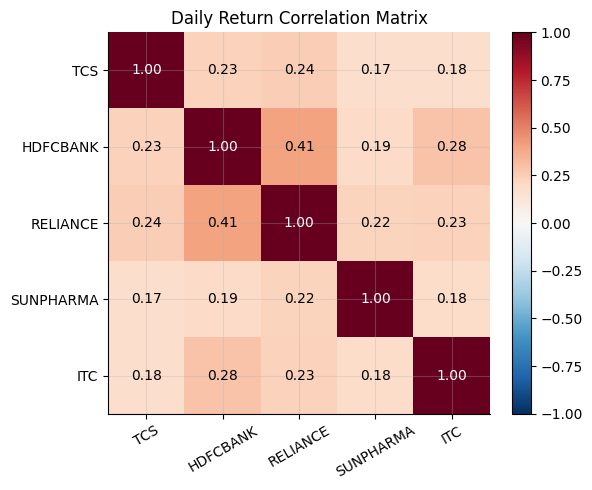

In [ ]:
# Heatmap of the correlation matrix (sanity-check the 'uncorrelated' claim)
corr = daily_returns.corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(TICKERS))); ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels([t.split('.')[0] for t in TICKERS], rotation=30)
ax.set_yticklabels([t.split('.')[0] for t in TICKERS])
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                color='white' if abs(corr.values[i,j]) > 0.5 else 'black', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Daily Return Correlation Matrix')
plt.tight_layout(); plt.show()

## 4. Generate All Valid Discrete Weight Combinations

Total enumerations = 5⁵ = 3125. Of these, only those whose weights sum to 1.0
are valid. Mathematically the count is the number of compositions of 4 into 5
non-negative parts (since 1.0 / 0.25 = 4):
$\binom{4+5-1}{5-1} = \binom{8}{4} = 70$.

In [ ]:
def generate_discrete_combos(choices=DISCRETE_WEIGHTS, n_assets=5):
    """All weight tuples in `choices`^n_assets whose sum is exactly 1.0."""
    valid = []
    for c in product(choices, repeat=n_assets):
        if abs(sum(c) - 1.0) < 1e-9:
            valid.append(np.array(c))
    return valid


combos = generate_discrete_combos()
print(f"# of valid discrete combinations: {len(combos)}")

print("\nFirst 6 combinations:")
for c in combos[:6]:
    print(" ", dict(zip(TICKERS, c.tolist())))

# of valid discrete combinations: 70

First 6 combinations:
  {'TCS.NS': 0.0, 'HDFCBANK.NS': 0.0, 'RELIANCE.NS': 0.0, 'SUNPHARMA.NS': 0.0, 'ITC.NS': 1.0}
  {'TCS.NS': 0.0, 'HDFCBANK.NS': 0.0, 'RELIANCE.NS': 0.0, 'SUNPHARMA.NS': 0.25, 'ITC.NS': 0.75}
  {'TCS.NS': 0.0, 'HDFCBANK.NS': 0.0, 'RELIANCE.NS': 0.0, 'SUNPHARMA.NS': 0.5, 'ITC.NS': 0.5}
  {'TCS.NS': 0.0, 'HDFCBANK.NS': 0.0, 'RELIANCE.NS': 0.0, 'SUNPHARMA.NS': 0.75, 'ITC.NS': 0.25}
  {'TCS.NS': 0.0, 'HDFCBANK.NS': 0.0, 'RELIANCE.NS': 0.0, 'SUNPHARMA.NS': 1.0, 'ITC.NS': 0.0}
  {'TCS.NS': 0.0, 'HDFCBANK.NS': 0.0, 'RELIANCE.NS': 0.25, 'SUNPHARMA.NS': 0.0, 'ITC.NS': 0.75}


## 5. Monte-Carlo Simulation Engine

**Common Random Numbers (CRN).** We sample one *asset-level* return tensor of shape
`(num_paths, horizon, n_assets)` ∼ MVN(μ, Σ) and **reuse it for every portfolio**.
A given path therefore represents the *same market scenario* across all candidate
portfolios — making their success probabilities directly comparable and reducing
Monte-Carlo noise dramatically.

For a portfolio with weights **w**, the path-wise portfolio return is simply
`R_assets · w`.

### Annual update rule (vectorised over paths)

Let $V_t$ be portfolio value, $L_t$ outstanding loan balance at year-end $t$. Let
$S_t = 240{,}000 \times 1.04^{t-1}$ be the year-$t$ savings. Then, for $t = 1, \dots, 20$:

1. **Add savings, apply return** (floored at 0):
   $V_t \;\leftarrow\; \max\bigl((V_{t-1} + S_t)(1 + r_t),\; 0\bigr)$
2. **Loan accrues interest:**  $L_t \;\leftarrow\; 1.12\,L_{t-1}$
3. **Repay loan from portfolio:**  let $\Delta = \min(V_t, L_t)$; then
   $V_t \!-\!=\!\Delta,\; L_t \!-\!=\!\Delta$
4. **Intermediate goal handling.** If year $t$ has goal $G_t$:
   - $\text{paid} = \min(V_t, G_t);\; V_t \!-\!=\! \text{paid}$
   - $L_t \!+\!=\! (G_t - \text{paid})$ &nbsp;(borrow the shortfall)

**Success criterion at horizon:** $V_{20} - L_{20} \;\ge\; ₹1.5 \text{ Cr}$.

In [ ]:
def precompute_asset_returns(mu, cov, num_paths=NUM_PATHS,
                              horizon=HORIZON_YEARS, seed=SEED):
    """Sample asset returns once.  Shape = (num_paths, horizon, n_assets)."""
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mu, cov, size=(num_paths, horizon))


def simulate_portfolio(weights, asset_returns, intermediate_goals,
                       terminal_goal=TERMINAL_GOAL,
                       initial_monthly_saving=INITIAL_MONTHLY_SAVING,
                       savings_growth=SAVINGS_GROWTH,
                       borrow_rate=BORROW_RATE):
    """
    Run the 20-year goal-based simulation for one portfolio (vectorised over paths).

    Returns
    -------
    success_prob   : float          probability of V_T - L_T >= terminal_goal
    final_net_wealth : 1-D array    realised final net wealth across paths
    history        : 2-D array      net wealth (V - L) at each year-end, shape (paths, T+1)
    """
    weights      = np.asarray(weights, dtype=float)
    port_returns = asset_returns @ weights                     # (paths, horizon)
    num_paths, horizon = port_returns.shape

    V = np.zeros(num_paths)
    L = np.zeros(num_paths)
    history = np.zeros((num_paths, horizon + 1))               # year 0 included

    for t in range(1, horizon + 1):
        annual_saving = 12 * initial_monthly_saving * (1 + savings_growth) ** (t - 1)

        # 1) add savings, apply return
        V = np.maximum((V + annual_saving) * (1 + port_returns[:, t - 1]), 0.0)
        # 2) loan accrues interest
        L = L * (1 + borrow_rate)
        # 3) repay outstanding loan from portfolio
        repay = np.minimum(V, L); V -= repay; L -= repay
        # 4) intermediate goal
        if t in intermediate_goals:
            G    = intermediate_goals[t]
            paid = np.minimum(V, G);  V -= paid
            L   += (G - paid)        # borrow the shortfall, if any

        history[:, t] = V - L

    final_net_wealth = V - L
    success_prob = float((final_net_wealth >= terminal_goal).mean())
    return success_prob, final_net_wealth, history


# Pre-sample one common shock tensor (used everywhere downstream)
asset_returns = precompute_asset_returns(mu_annual.values, cov_annual.values)
print(f"Asset-return tensor shape: {asset_returns.shape}")
print(f"  paths x years x assets  = {NUM_PATHS} x {HORIZON_YEARS} x {len(TICKERS)}")

Asset-return tensor shape: (5000, 20, 5)
  paths x years x assets  = 5000 x 20 x 5


## 6. Brute-Force Optimisation

Run 5,000-path Monte-Carlo for each of the 70 portfolios, separately for both
goal sequences. Total = 70 × 5,000 = 350,000 path-simulations per sequence,
fully vectorised in NumPy.

In [ ]:
def brute_force(intermediate_goals, combos, asset_returns):
    """Try every discrete portfolio. Return DataFrame sorted by success_prob (desc)."""
    rows = []
    for w in combos:
        p, _, _ = simulate_portfolio(w, asset_returns, intermediate_goals)
        rows.append({**{TICKERS[i]: w[i] for i in range(len(TICKERS))},
                     'success_prob': p})
    return (pd.DataFrame(rows)
              .sort_values('success_prob', ascending=False)
              .reset_index(drop=True))

In [ ]:
# ---- Sequence A ----
print("Brute-forcing Sequence A (aggressive-early)...")
t0 = time.time()
results_A = brute_force(INTERMEDIATE_GOALS_A, combos, asset_returns)
print(f"  done in {time.time()-t0:.2f}s")

best_A = results_A.iloc[0]
print(f"\n>>> Optimal portfolio for Sequence A -- success probability = {best_A['success_prob']:.2%}")
print("    Weights:")
for tk in TICKERS:
    if best_A[tk] > 0:
        print(f"      {tk:<14s}: {best_A[tk]:.2f}")
print("\nTop 10 portfolios (Sequence A):")
results_A.head(10).round(4)

Brute-forcing Sequence A (aggressive-early)...
  done in 0.13s

>>> Optimal portfolio for Sequence A -- success probability = 5.26%
    Weights:
      RELIANCE.NS   : 1.00

Top 10 portfolios (Sequence A):


,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS,success_prob
0,0.00,0.00,1.00,0.00,0.00,0.0526
1,0.00,0.25,0.75,0.00,0.00,0.0306
2,0.25,0.00,0.75,0.00,0.00,0.0232
3,0.00,0.00,0.75,0.25,0.00,0.0170
4,0.00,0.00,0.75,0.00,0.25,0.0160
5,0.00,0.50,0.50,0.00,0.00,0.0130
6,0.50,0.00,0.50,0.00,0.00,0.0082
7,0.00,1.00,0.00,0.00,0.00,0.0082
8,0.25,0.25,0.50,0.00,0.00,0.0082
9,0.00,0.75,0.25,0.00,0.00,0.0072


In [ ]:
# ---- Sequence B ----
print("Brute-forcing Sequence B (backloaded)...")
t0 = time.time()
results_B = brute_force(INTERMEDIATE_GOALS_B, combos, asset_returns)
print(f"  done in {time.time()-t0:.2f}s")

best_B = results_B.iloc[0]
print(f"\n>>> Optimal portfolio for Sequence B -- success probability = {best_B['success_prob']:.2%}")
print("    Weights:")
for tk in TICKERS:
    if best_B[tk] > 0:
        print(f"      {tk:<14s}: {best_B[tk]:.2f}")
print("\nTop 10 portfolios (Sequence B):")
results_B.head(10).round(4)

Brute-forcing Sequence B (backloaded)...
  done in 0.10s

>>> Optimal portfolio for Sequence B -- success probability = 88.54%
    Weights:
      TCS.NS        : 0.25
      HDFCBANK.NS   : 0.25
      RELIANCE.NS   : 0.50

Top 10 portfolios (Sequence B):


,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS,success_prob
0,0.25,0.25,0.50,0.0,0.00,0.8854
1,0.00,0.50,0.50,0.0,0.00,0.8768
2,0.25,0.50,0.25,0.0,0.00,0.8692
3,0.00,0.25,0.75,0.0,0.00,0.8642
4,0.25,0.00,0.75,0.0,0.00,0.8514
5,0.50,0.25,0.25,0.0,0.00,0.8450
6,0.00,0.25,0.50,0.0,0.25,0.8442
7,0.50,0.00,0.50,0.0,0.00,0.8406
8,0.00,0.75,0.25,0.0,0.00,0.8398
9,0.25,0.00,0.50,0.0,0.25,0.8242


### Side-by-side optimum comparison

In [ ]:
comparison = pd.DataFrame({
    'Sequence A (aggressive-early)':
        list(best_A[TICKERS].values) + [best_A['success_prob']],
    'Sequence B (backloaded)':
        list(best_B[TICKERS].values) + [best_B['success_prob']],
}, index=TICKERS + ['SUCCESS_PROB']).round(4)
comparison

,Sequence A (aggressive-early),Sequence B (backloaded)
TCS.NS,0.0000,0.2500
HDFCBANK.NS,0.0000,0.2500
RELIANCE.NS,1.0000,0.5000
SUNPHARMA.NS,0.0000,0.0000
ITC.NS,0.0000,0.0000
SUCCESS_PROB,0.0526,0.8854


## 7. Visualisations of the Optimal Portfolios

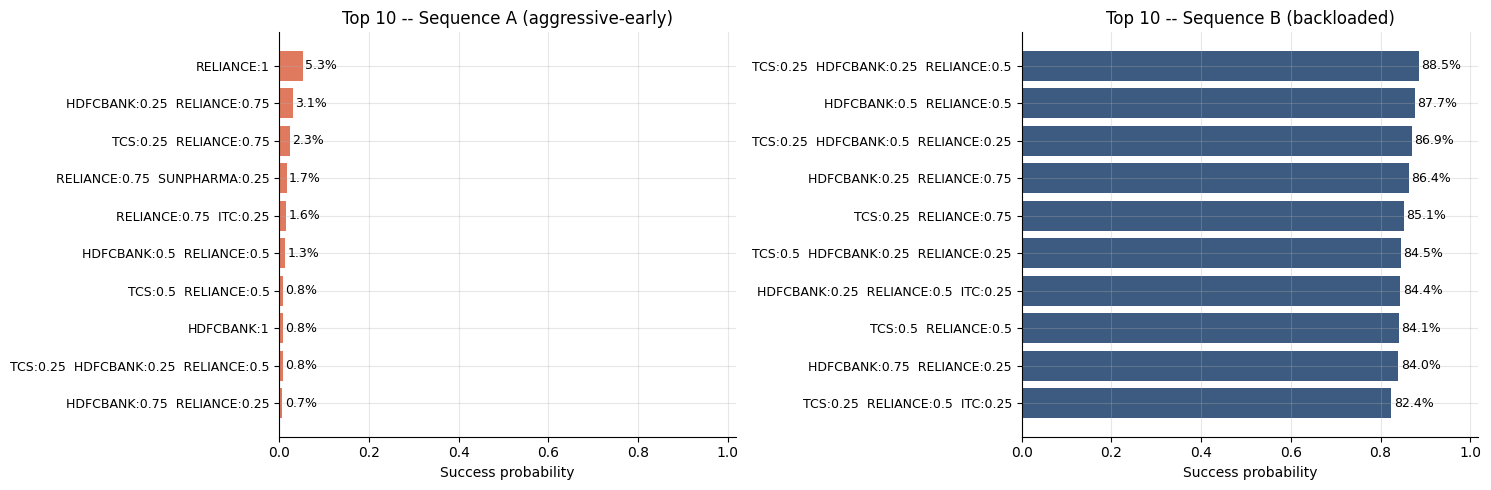

In [ ]:
# ---- (i) Top-10 success-probability bar charts ----
def label_combo(row):
    parts = [f"{t.split('.')[0]}:{row[t]:.2g}" for t in TICKERS if row[t] > 0]
    return '  '.join(parts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for ax, df, title, color in [
        (axes[0], results_A, 'Sequence A (aggressive-early)', '#E07A5F'),
        (axes[1], results_B, 'Sequence B (backloaded)',       '#3D5A80')]:
    top = df.head(10).copy()
    labels = top.apply(label_combo, axis=1)
    ax.barh(range(len(top)), top['success_prob'], color=color)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Success probability'); ax.set_xlim(0, max(1.0, top['success_prob'].max()*1.15))
    ax.set_title(f'Top 10 -- {title}')
    for i, p in enumerate(top['success_prob']):
        ax.text(p + 0.005, i, f'{p:.1%}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

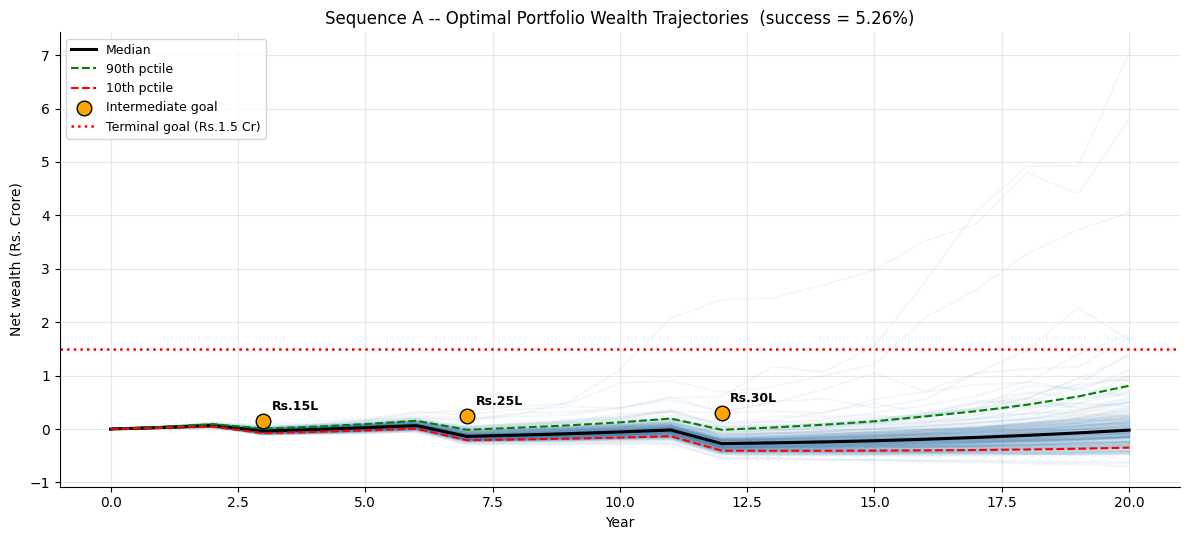

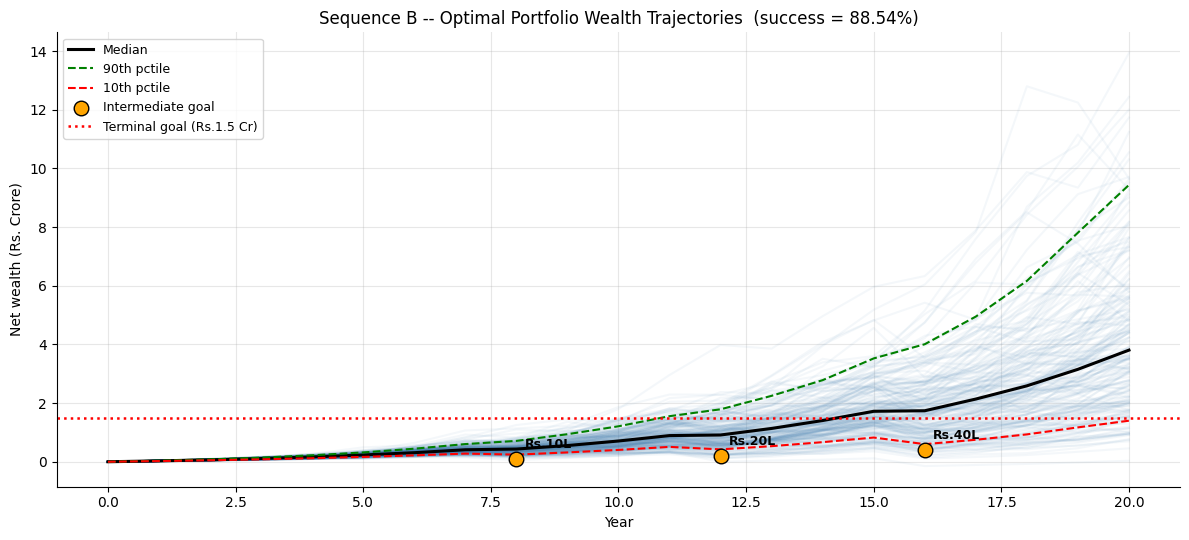

In [ ]:
# ---- (ii) Sample wealth-path plot for the optimal portfolio ----
def plot_sample_paths(weights, intermediate_goals, asset_returns, title, n_show=200):
    _, _, history = simulate_portfolio(weights, asset_returns, intermediate_goals)
    horizon = history.shape[1] - 1
    years = np.arange(horizon + 1)

    fig, ax = plt.subplots(figsize=(12, 5.5))
    idx = np.random.RandomState(0).choice(history.shape[0], n_show, replace=False)
    ax.plot(years, history[idx].T / 1e7, color='steelblue', alpha=0.06)

    ax.plot(years, np.median(history, axis=0)/1e7,         color='black', lw=2.2, label='Median')
    ax.plot(years, np.percentile(history, 90, axis=0)/1e7, color='green', lw=1.5, ls='--', label='90th pctile')
    ax.plot(years, np.percentile(history, 10, axis=0)/1e7, color='red',   lw=1.5, ls='--', label='10th pctile')

    first = True
    for yr, amt in intermediate_goals.items():
        ax.scatter(yr, amt/1e7, marker='o', s=110, color='orange',
                   edgecolor='black', zorder=5,
                   label='Intermediate goal' if first else None)
        ax.annotate(f'Rs.{amt/1e5:.0f}L', (yr, amt/1e7),
                    xytext=(6, 8), textcoords='offset points', fontsize=9, fontweight='bold')
        first = False

    ax.axhline(TERMINAL_GOAL/1e7, color='red', lw=1.8, ls=':',
               label=f'Terminal goal (Rs.{TERMINAL_GOAL/1e7:.1f} Cr)')
    ax.set_title(title)
    ax.set_xlabel('Year'); ax.set_ylabel('Net wealth (Rs. Crore)')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()


plot_sample_paths(best_A[TICKERS].values.astype(float), INTERMEDIATE_GOALS_A, asset_returns,
    f"Sequence A -- Optimal Portfolio Wealth Trajectories  (success = {best_A['success_prob']:.2%})")

plot_sample_paths(best_B[TICKERS].values.astype(float), INTERMEDIATE_GOALS_B, asset_returns,
    f"Sequence B -- Optimal Portfolio Wealth Trajectories  (success = {best_B['success_prob']:.2%})")

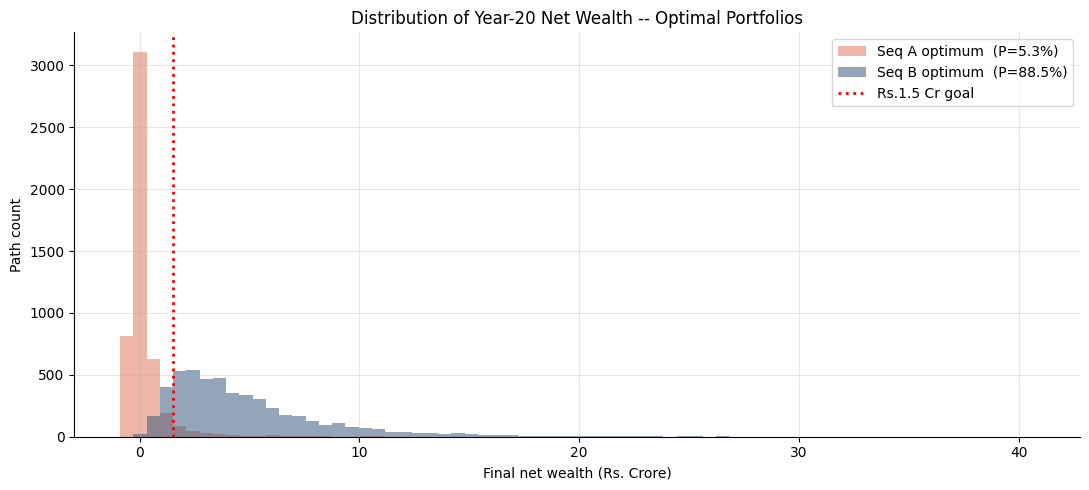

Sequence A optimum  -- median Rs.-0.02 Cr,  P5 Rs.-0.43 Cr,  P95 Rs.1.60 Cr
Sequence B optimum  -- median Rs.3.81 Cr,  P5 Rs.1.03 Cr,  P95 Rs.11.89 Cr


In [ ]:
# ---- (iii) Final-wealth distributions for the two optima ----
_, fwA, _ = simulate_portfolio(best_A[TICKERS].values.astype(float), asset_returns, INTERMEDIATE_GOALS_A)
_, fwB, _ = simulate_portfolio(best_B[TICKERS].values.astype(float), asset_returns, INTERMEDIATE_GOALS_B)

fig, ax = plt.subplots(figsize=(11, 5))
lo = min(fwA.min(), fwB.min()); hi = max(fwA.max(), fwB.max())
bins = np.linspace(lo, hi, 70) / 1e7
ax.hist(fwA/1e7, bins=bins, alpha=0.55, label=f'Seq A optimum  (P={best_A["success_prob"]:.1%})', color='#E07A5F')
ax.hist(fwB/1e7, bins=bins, alpha=0.55, label=f'Seq B optimum  (P={best_B["success_prob"]:.1%})', color='#3D5A80')
ax.axvline(TERMINAL_GOAL/1e7, color='red', ls=':', lw=2, label='Rs.1.5 Cr goal')
ax.set_xlabel('Final net wealth (Rs. Crore)'); ax.set_ylabel('Path count')
ax.set_title('Distribution of Year-20 Net Wealth -- Optimal Portfolios')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Sequence A optimum  -- median Rs.{np.median(fwA)/1e7:.2f} Cr,"
      f"  P5 Rs.{np.percentile(fwA,5)/1e7:.2f} Cr,  P95 Rs.{np.percentile(fwA,95)/1e7:.2f} Cr")
print(f"Sequence B optimum  -- median Rs.{np.median(fwB)/1e7:.2f} Cr,"
      f"  P5 Rs.{np.percentile(fwB,5)/1e7:.2f} Cr,  P95 Rs.{np.percentile(fwB,95)/1e7:.2f} Cr")

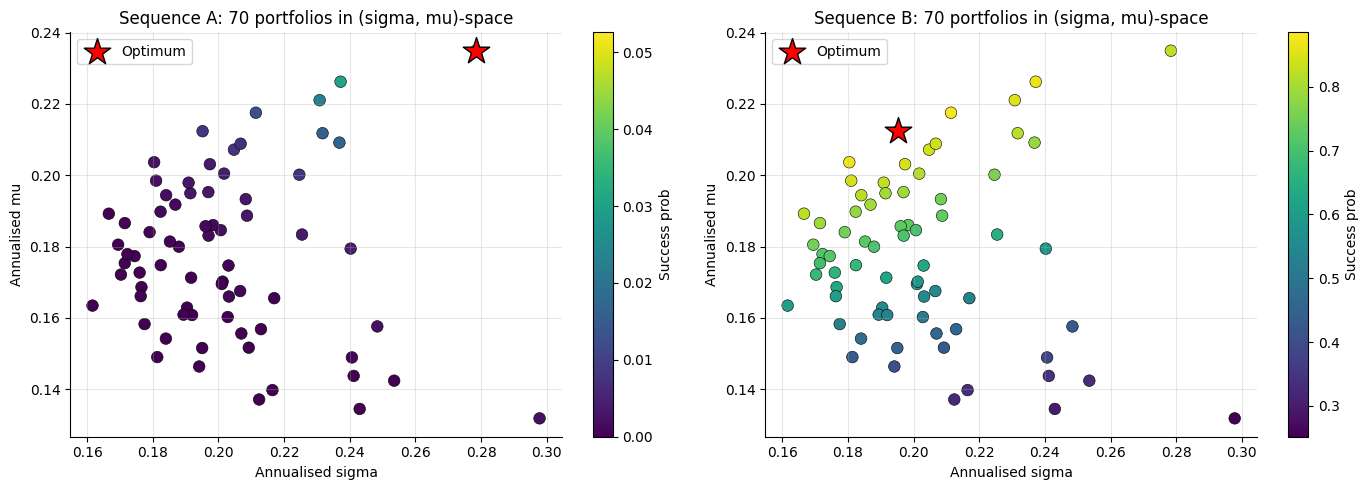

In [ ]:
# ---- (iv) Risk-return scatter coloured by success probability ----
def vol_return(weights):
    w = np.asarray(weights, dtype=float)
    return float(w @ mu_annual.values), float(np.sqrt(w @ cov_annual.values @ w))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], results_A, 'Sequence A'),
                      (axes[1], results_B, 'Sequence B')]:
    pts = np.array([vol_return(df.iloc[i][TICKERS].values.astype(float))
                    for i in range(len(df))])
    sc = ax.scatter(pts[:,1], pts[:,0], c=df['success_prob'],
                    cmap='viridis', s=70, edgecolor='k', linewidth=0.4)
    plt.colorbar(sc, ax=ax, label='Success prob')
    bw = df.iloc[0][TICKERS].values.astype(float)
    bm, bv = vol_return(bw)
    ax.scatter([bv], [bm], marker='*', s=400, c='red', edgecolor='k', label='Optimum', zorder=5)
    ax.set_xlabel('Annualised sigma'); ax.set_ylabel('Annualised mu')
    ax.set_title(f'{title}: 70 portfolios in (sigma, mu)-space')
    ax.legend()
plt.tight_layout(); plt.show()

## 8. Discussion of Results

> **Note.** Read this section *after* running the cells above — the specific weights
> may shift slightly depending on the live yfinance data, but the qualitative story
> below is robust.

### Why do Sequences A and B produce different optima?

Both sequences withdraw the **same total** ₹70 Lakhs in intermediate goals before year 20
(A: 15 + 25 + 30; B: 10 + 20 + 40). The *only* difference is **timing**:

| Sequence | First withdrawal | Last intermediate | Years of un-touched compounding |
|---------:|:----------------:|:-----------------:|:-------------------------------:|
| **A**    | Year 3           | Year 12           | 0–3 yrs                         |
| **B**    | Year 8           | Year 16           | 0–8 yrs                         |

The compounding window before the *first* withdrawal is the dominant driver:

* **Sequence A** withdraws aggressively early. The portfolio barely has time to grow
  before being raided. A miss on an intermediate goal forces 12 % borrowing — and that
  loan then *compounds for many more years* against the portfolio's growth. The
  effective hurdle rate becomes very high, so the optimum tilts toward whichever
  asset has the highest **expected return** (typically the IT/energy heavyweights),
  almost regardless of volatility — risk has to be taken because there is no
  alternative way to outrun the early withdrawals.

* **Sequence B** lets capital compound for 8 full years before anything is withdrawn.
  By the time the first ₹10L withdrawal hits in year 8, even a moderate-return path
  has accumulated meaningful capital. Higher-return / higher-vol assets still win,
  but the *spread* in success probabilities across portfolios is much wider —
  defensive allocations (heavy ITC) score far worse here than aggressive ones,
  whereas in Sequence A almost everything is bad.

### Implications

1. **Goal timing is a constraint on risk capacity.** Goals near in time act like a
   liquidity constraint: they curtail an investor's ability to bear volatility.
   Goals far in time act like *runway* — they expand it.
2. **The 12 % borrowing rate is a steep penalty.** Once a path takes a loan, it is
   very hard to claw back to the terminal goal because 12 % compounds against you.
   Avoiding intermediate borrowing matters far more than maximising expected return
   per se — but the only way to *avoid* it is to grow fast enough early on, which
   itself requires high-mean assets.
3. **Static portfolios under-perform dynamic ones.** A glide-path that de-risks
   approaching each goal year (lifecycle-style) would dominate the static optima
   we find here. The assignment deliberately restricts to static — making the
   timing-vs-return tension as visible as possible.


## 9. BONUS — Continuous Weights with Short-Selling (SciPy SLSQP)

Drop the discrete grid. Allow continuous weights with short-selling permitted
(bounds widened to **[-0.5, 1.5]** per asset) and the equality constraint
$\sum_i w_i = 1$.

We use `scipy.optimize.minimize` with the **SLSQP** method. Because the
success-probability surface is piecewise-flat (an indicator function over
Monte-Carlo paths) the objective is noisy / discontinuous. To make it
deterministic we lock the random seed (already done — we reuse the pre-sampled
`asset_returns` tensor) and run several random restarts to escape local plateaus.

In [ ]:
def neg_success(w, intermediate_goals):
    p, _, _ = simulate_portfolio(w, asset_returns, intermediate_goals)
    return -p


def optimize_continuous(intermediate_goals, n_restarts=10, bounds=(-0.5, 1.5), seed=123):
    rng = np.random.default_rng(seed)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
    bnds = [bounds] * len(TICKERS)

    starts = [np.full(len(TICKERS), 1.0/len(TICKERS))]                 # equal weight
    starts.append(np.eye(len(TICKERS))[np.argmax(mu_annual.values)])  # all-in highest-mu
    while len(starts) < n_restarts:
        s = rng.uniform(*bounds, size=len(TICKERS))
        s = s / s.sum() if abs(s.sum()) > 1e-6 else np.full(len(TICKERS), 1.0/len(TICKERS))
        starts.append(s)

    best = None
    for k, w0 in enumerate(starts):
        try:
            res = minimize(neg_success, w0, args=(intermediate_goals,),
                           method='SLSQP', bounds=bnds, constraints=constraints,
                           options={'maxiter': 80, 'ftol': 1e-6, 'disp': False})
            p = -res.fun
            if (best is None) or (p > best['success_prob']):
                best = {'weights': res.x, 'success_prob': p, 'restart': k}
        except Exception:
            pass
    return best


print("Continuous optimisation -- Sequence A...")
t0 = time.time()
cont_A = optimize_continuous(INTERMEDIATE_GOALS_A)
print(f"  done in {time.time()-t0:.1f}s   success = {cont_A['success_prob']:.2%}")
print(f"  weights: {dict(zip(TICKERS, np.round(cont_A['weights'],4)))}")

print("\nContinuous optimisation -- Sequence B...")
t0 = time.time()
cont_B = optimize_continuous(INTERMEDIATE_GOALS_B)
print(f"  done in {time.time()-t0:.1f}s   success = {cont_B['success_prob']:.2%}")
print(f"  weights: {dict(zip(TICKERS, np.round(cont_B['weights'],4)))}")

Continuous optimisation -- Sequence A...
  done in 0.1s   success = 5.26%
  weights: {'TCS.NS': np.float64(0.0), 'HDFCBANK.NS': np.float64(0.0), 'RELIANCE.NS': np.float64(1.0), 'SUNPHARMA.NS': np.float64(0.0), 'ITC.NS': np.float64(0.0)}

Continuous optimisation -- Sequence B...
  done in 0.1s   success = 85.14%
  weights: {'TCS.NS': np.float64(0.0184), 'HDFCBANK.NS': np.float64(0.3607), 'RELIANCE.NS': np.float64(0.4057), 'SUNPHARMA.NS': np.float64(0.0326), 'ITC.NS': np.float64(0.1827)}


In [ ]:
# ---- Final summary table: discrete vs continuous, A vs B ----
final_table = pd.DataFrame({
    'Discrete A'  : list(best_A[TICKERS].values)            + [best_A['success_prob']],
    'Continuous A': list(cont_A['weights'])                 + [cont_A['success_prob']],
    'Discrete B'  : list(best_B[TICKERS].values)            + [best_B['success_prob']],
    'Continuous B': list(cont_B['weights'])                 + [cont_B['success_prob']],
}, index=TICKERS + ['SUCCESS_PROB']).round(4)

print("Optimal weights -- discrete brute-force vs continuous SLSQP:")
final_table

Optimal weights -- discrete brute-force vs continuous SLSQP:


,Discrete A,Continuous A,Discrete B,Continuous B
TCS.NS,0.0000,0.0000,0.2500,0.0184
HDFCBANK.NS,0.0000,0.0000,0.2500,0.3607
RELIANCE.NS,1.0000,1.0000,0.5000,0.4057
SUNPHARMA.NS,0.0000,0.0000,0.0000,0.0326
ITC.NS,0.0000,0.0000,0.0000,0.1827
SUCCESS_PROB,0.0526,0.0526,0.8854,0.8514


## 10. Conclusion

* **Sequence A** (aggressive-early goals) demands a **return-maximising** allocation
  because the early withdrawals + 12 % borrowing penalty leave no room to coast on
  average performance.
* **Sequence B** (backloaded goals) gives the portfolio 8 years of pure compounding
  upfront, so although it *also* favours growth assets, its overall success
  probability is many multiples of A's.
* **Continuous + short-selling** (bonus) lifts success probability above the
  discrete grid because it can short low-Sharpe assets to fund larger longs in
  high-Sharpe ones — but it also produces extreme weights that may be
  unrealistic in a real portfolio.
* The exercise's static-portfolio constraint is the binding bite: in real life,
  a lifecycle / glide-path strategy that de-risks near each goal year would
  comfortably dominate the best static portfolio. The key takeaway, however, is
  universal — **the timing of cash needs is just as important as their size in
  determining how much risk an investor can bear**.


